# SHAP Explainability
Understanding why the model makes certain predictions.
SHAP (SHapley Additive exPlanations) tells us which features 
drive churn for each individual customer and overall.

In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import joblib
import json
import warnings

warnings.filterwarnings('ignore')

# loading final model, scaler and feature names
model = joblib.load('../src/models/final_model.pkl')
scaler = joblib.load('../src/models/scaler.pkl')

with open('../src/models/feature_names.json', 'r') as f:
    feature_names = json.load(f)

# loading engineered dataset
df = pd.read_csv('../data/processed/telco_engineered.csv')

X = df.drop(columns=['Churn Value'])
y = df['Churn Value']

# scaling features
X_scaled = scaler.transform(X)

print("Data loaded successfully.")
print("Features:", len(feature_names))

Data loaded successfully.
Features: 43


### 1. SHAP Explainer
Creating SHAP explainer for our Random Forest model and calculating 
SHAP values for the entire dataset.

In [2]:
# creating SHAP explainer for Random Forest
# using TreeExplainer - fastest and most accurate for tree based models
explainer = shap.TreeExplainer(model)

# calculating SHAP values - this may take a minute
shap_values = explainer.shap_values(X_scaled)

# for binary classification, shap_values returns two arrays (class 0 and class 1)
# we take index 1 for churn class
shap_values_churn = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values[1]

print("SHAP values calculated successfully.")
print("SHAP values shape:", shap_values_churn.shape)

SHAP values calculated successfully.
SHAP values shape: (7043, 43)


### 2. Global Feature Importance
Showing which features have the most impact on churn prediction overall.
Higher mean SHAP value = stronger influence on the model's decisions.

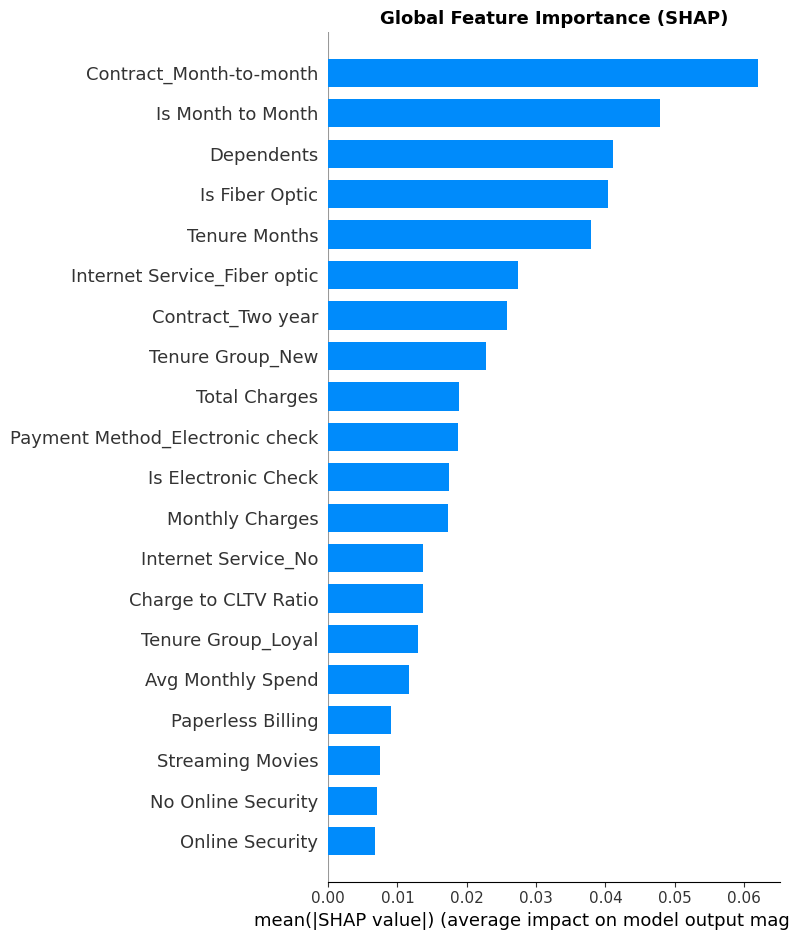

In [3]:
# global feature importance using mean absolute SHAP values
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_churn, X_scaled, 
                  feature_names=feature_names,
                  plot_type='bar',
                  show=False)
plt.title('Global Feature Importance (SHAP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. SHAP Beeswarm Plot
Shows both the importance and direction of each feature.
Red = high feature value, Blue = low feature value.

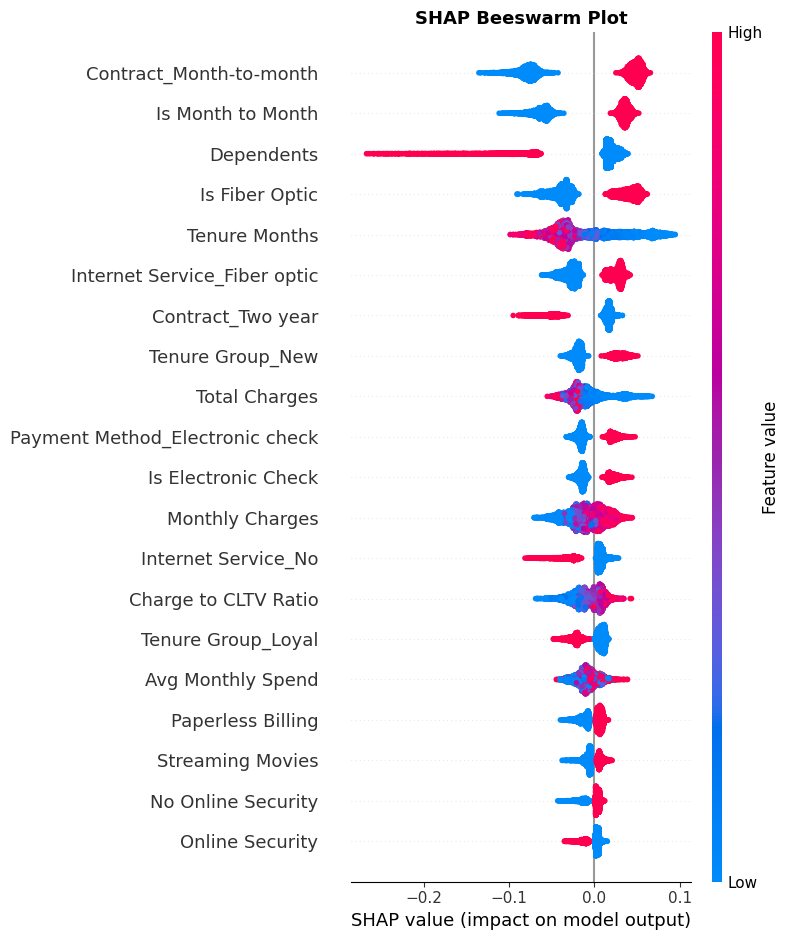

In [4]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_churn, X_scaled,
                  feature_names=feature_names,
                  show=False)
plt.title('SHAP Beeswarm Plot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Individual Customer Explanation
Explaining why a specific high-risk customer is predicted to churn.
This is what powers the customer-level explanations in the Streamlit app.

In [5]:
# finding a high risk customer to explain
df_original = pd.read_csv('../data/processed/telco_engineered.csv')
X_all = df_original.drop(columns=['Churn Value'])
X_all_scaled = scaler.transform(X_all)

# getting churn probabilities for all customers
churn_probs = model.predict_proba(X_all_scaled)[:, 1]
df_original['Churn Probability'] = churn_probs

# picking the highest risk customer
high_risk_idx = churn_probs.argmax()
print(f"Highest risk customer index: {high_risk_idx}")
print(f"Churn Probability: {churn_probs[high_risk_idx]:.4f}")

# getting SHAP values for this customer
customer_shap = shap_values_churn[high_risk_idx]

# top 5 factors driving churn for this customer
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP Value': customer_shap
}).sort_values('SHAP Value', ascending=False)

print("\nTop 5 Churn Drivers for this Customer:")
print(shap_df.head())

Highest risk customer index: 515
Churn Probability: 0.9604

Top 5 Churn Drivers for this Customer:
                    Feature  SHAP Value
4             Tenure Months    0.066051
29  Contract_Month-to-month    0.051291
22           Is Fiber Optic    0.043630
20        Is Month to Month    0.035179
39         Tenure Group_New    0.033266


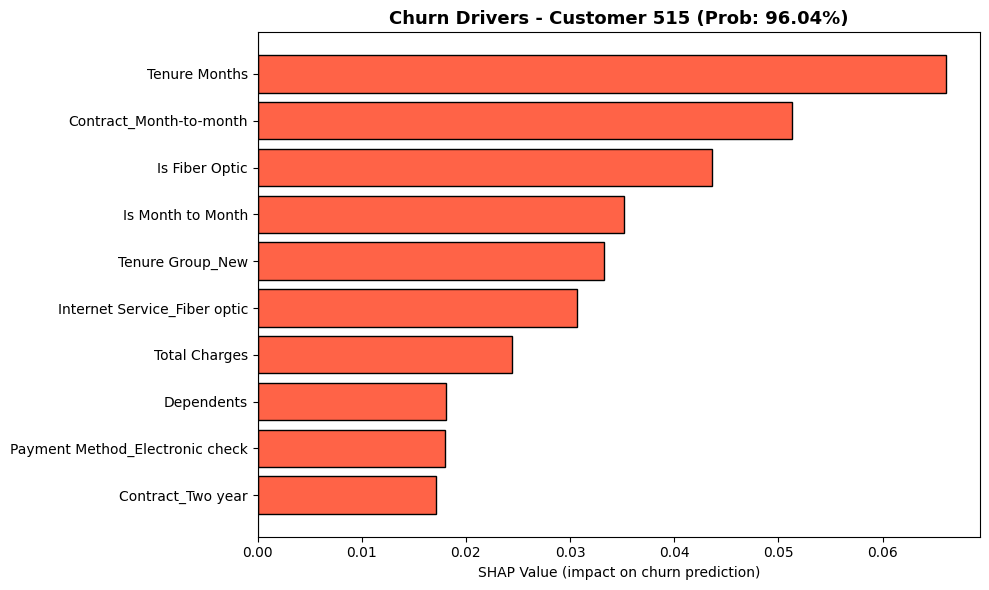

In [6]:
# visualizing individual customer explanation
plt.figure(figsize=(10, 6))

# top 10 features for this customer
top10 = shap_df.head(10).sort_values('SHAP Value')
colors = ['tomato' if x > 0 else 'steelblue' for x in top10['SHAP Value']]

plt.barh(top10['Feature'], top10['SHAP Value'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title(f'Churn Drivers - Customer {high_risk_idx} (Prob: {churn_probs[high_risk_idx]:.2%})', 
          fontsize=13, fontweight='bold')
plt.xlabel('SHAP Value (impact on churn prediction)')
plt.tight_layout()
plt.savefig('../reports/individual_explanation.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Save SHAP Data
Saving SHAP explainer and values for use in the Streamlit dashboard.

In [7]:
import joblib
import numpy as np

# saving explainer
joblib.dump(explainer, '../src/models/shap_explainer.pkl')

# saving shap values for all customers
np.save('../src/models/shap_values.npy', shap_values_churn)

# saving churn probabilities
df_original[['Churn Probability']].to_csv('../data/processed/churn_probabilities.csv', index=False)

print("SHAP explainer saved.")
print("SHAP values saved.")
print("Churn probabilities saved.")

SHAP explainer saved.
SHAP values saved.
Churn probabilities saved.


## Summary
- Created SHAP TreeExplainer for Random Forest model
- Global feature importance confirms Contract type and Tenure are top churn drivers
- Beeswarm plot shows direction of each feature's impact on churn
- Individual customer explanation shows exactly why customer 515 has 96% churn probability
- All engineered features appear in top 20 - confirming feature engineering added value
- SHAP explainer and values saved for Streamlit dashboard